# Portafolio de acciones — Prophet + backtesting

Descargamos **5 acciones** (desde 2010) con **yfinance**, armamos un portafolio equiponderado, entrenamos **Prophet** hasta 2023 y comparamos lo **real vs lo predicho** en **2024 a la fecha**.

| Sección | Tema |
|---------|------|
| **1** | Portafolio (5 tickers, train / test) |
| **2** | Prophet por acción y portafolio |
| **3** | Backtesting: real vs predicho + MAPE |


## ¿Qué es Prophet?

**Prophet no es una red neuronal.** Es un modelo de **series de tiempo** (Meta) para forecasting interpretable: descompone la serie en partes que puedes explicar.

```
y(t) ≈ tendencia + estacionalidad + festivos + ruido
```

| Pregunta | Respuesta corta |
|----------|-----------------|
| ¿Es deep learning? | **No.** No hay capas ni backprop. |
| ¿Cómo “entrena”? | Ajusta coeficientes con **Stan** (inferencia bayesiana / MAP). En código: `m.fit(train)` → `m.predict(futuro)`. |
| ¿Qué aprende? | Pendiente de la tendencia (con quiebres), ondas de estacionalidad (Fourier) y efecto de festivos. |
| ¿Para qué sirve? | Métricas con patrón claro: ventas, tráfico, usuarios… En acciones funciona **limitado** (noticias y shocks no los modela). |

**Prophet vs red neuronal (LSTM, etc.)**

| | Prophet | Red neuronal |
|--|---------|----------------|
| Estructura | Fórmula fija (tendencia + Fourier) | Capas que aprenden representaciones |
| Datos | Pocos, serie regular en el tiempo | Muchos suelen ayudar |
| Interpretación | Alta | Baja (caja negra) |

En este notebook usamos **backtesting**: entrenamos con 2010–2023 y medimos qué tan bien Prophet reproduce **2024 → hoy**. No es consejo de inversión — es práctica de forecasting.

## Setup

```bash
pip install prophet yfinance pandas matplotlib
```


In [1]:
#%pip install -q prophet yfinance pandas matplotlib

In [2]:
import warnings
warnings.filterwarnings("ignore")

from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from prophet import Prophet

TICKERS = ["AAPL", "MSFT", "JPM", "XOM", "JNJ"]

INICIO = "2010-01-01"
FIN = date.today().strftime("%Y-%m-%d")
FECHA_CORTE = "2024-01-01"  # train: 2010–2023 | backtest: 2024 → hoy

# Ajustes para acciones (el Prophet default queda muy plano)
PROPHET_KWARGS = dict(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,  # default 0.05 = curva muy rígida
    changepoint_range=0.95,         # quiebres hasta casi el final del train
)


def crear_prophet():
    m = Prophet(**PROPHET_KWARGS)
    m.add_country_holidays("US")
    return m

## 1 — Portafolio equiponderado

Descargamos el **cierre** de las 5 acciones. Cada una se normaliza a 100 en el inicio; el **portafolio** es el promedio (mismo peso para cada una).

Prophet necesita columnas **`ds`** (fecha) y **`y`** (valor).


In [3]:
precios = yf.download(TICKERS, start=INICIO, end=FIN, progress=False)["Close"].dropna()

# normalizar cada acción a 100 al inicio → portafolio equiponderado
normalizado = precios / precios.iloc[0] * 100
portafolio = normalizado.mean(axis=1)

def a_prophet(serie):
    df = serie.reset_index()
    df.columns = ["ds", "y"]
    df["ds"] = pd.to_datetime(df["ds"]).dt.tz_localize(None)
    return df

datos = {t: a_prophet(precios[t]) for t in TICKERS}
datos["PORTAFOLIO"] = a_prophet(portafolio)

train = {k: v[v["ds"] < FECHA_CORTE].copy() for k, v in datos.items()}
test = {k: v[v["ds"] >= FECHA_CORTE].copy() for k, v in datos.items()}

print(f"Periodo: {INICIO} → {FIN} | train antes de {FECHA_CORTE} | backtest desde {FECHA_CORTE}")
print(f"Días train: {len(train['AAPL'])} | días test: {len(test['AAPL'])}")
datos["PORTAFOLIO"].tail(3)

Periodo: 2010-01-01 → 2026-06-26 | train antes de 2024-01-01 | backtest desde 2024-01-01
Días train: 3522 | días test: 622


,ds,y
4141,2026-06-23,1674.231735
4142,2026-06-24,1662.016296
4143,2026-06-25,1598.542352


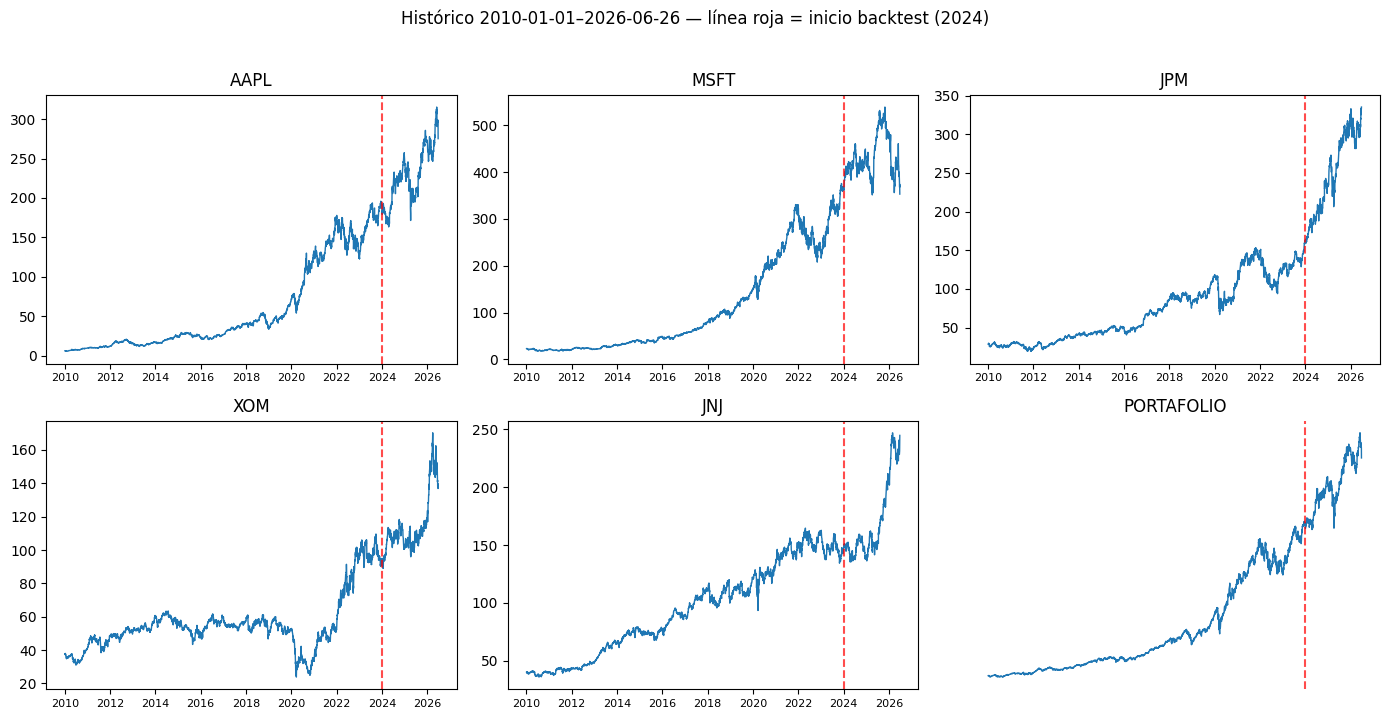

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, nombre in enumerate(list(TICKERS) + ["PORTAFOLIO"]):
    ax = axes[i]
    df = datos[nombre]
    ax.plot(df["ds"], df["y"], linewidth=1)
    ax.axvline(pd.to_datetime(FECHA_CORTE), color="red", linestyle="--", alpha=0.7)
    ax.set_title(nombre)
    ax.tick_params(axis="x", labelsize=8)

axes[-1].axis("off")
fig.suptitle(f"Histórico {INICIO}–{FIN} — línea roja = inicio backtest (2024)", y=1.02)
plt.tight_layout()
plt.show()

## 2 — Prophet (train 2010–2023)

El Prophet **default** suele quedar **muy plano** en acciones (subestima rallies como 2024–2025). Por eso aplicamos:

| Ajuste | Por qué |
|--------|---------|
| **`log(y)`** | Las acciones crecen en **%**, no en puntos fijos |
| **`changepoint_prior_scale=0.5`** | Tendencia más flexible (default `0.05` es muy rígida) |
| **`changepoint_range=0.95`** | Permite quiebres cerca del corte → captura momentum reciente |
| **`seasonality_mode='multiplicative'`** | Estacionalidad escala con el nivel de la serie |
| **Festivos US** | Días sin mercado |

Entrenamos un modelo **por acción** y otro para el **portafolio**. El backtest sigue siendo 2024 → hoy.


### Hiperparámetros de `Prophet(...)`

Prophet descompone la serie en **tendencia + estacionalidad + festivos + ruido**. En este notebook usamos:

```python
Prophet(
    daily_seasonality=False,
    weekly_seasonality=True,
    yearly_seasonality=True,
    seasonality_mode="multiplicative",
    changepoint_prior_scale=0.5,
    changepoint_range=0.95,
)
m.add_country_holidays("US")
# y entrenamos con y = log(precio), luego exp() al predecir
```

Abajo, los parámetros más útiles (los demás tienen default razonable para empezar).

#### Tendencia

| Parámetro | Default | Para qué sirve |
|-----------|---------|----------------|
| `growth` | `'linear'` | Forma de la tendencia: `'linear'` (crece sin tope), `'logistic'` (crece y se aplana — requiere columna `cap` en los datos), `'flat'` (sin tendencia). |
| `changepoints` | `None` | Fechas fijas donde la tendencia puede cambiar de pendiente. `None` = Prophet las elige solo. |
| `n_changepoints` | `25` | Cuántos puntos de quiebre **potenciales** repartidos en el histórico. |
| `changepoint_range` | `0.8` | Fracción del histórico donde se permiten quiebres (0.8 = solo el 80% inicial; evita overfitting al final). |
| `changepoint_prior_scale` | `0.05` | Qué tan flexible es la tendencia. **Alto** → muchos quiebres (puede sobreajustar). **Bajo** → curva más suave. |

#### Estacionalidad

| Parámetro | Default | Para qué sirve |
|-----------|---------|----------------|
| `yearly_seasonality` | `'auto'` | Estacionalidad anual. `True`/`False`, `'auto'`, o un entero (orden de Fourier = más detalle). En acciones diarias suele ayudar. |
| `weekly_seasonality` | `'auto'` | Estacionalidad semanal (patrones por día de la semana). |
| `daily_seasonality` | `'auto'` | Estacionalidad diaria (patrones intra-día). En **datos diarios** conviene `False` — no hay múltiples observaciones por día. |
| `seasonality_mode` | `'additive'` | `'additive'`: efecto estacional se **suma** a la tendencia. `'multiplicative'`: se **multiplica** (útil si la estacionalidad crece con el nivel de la serie). |
| `seasonality_prior_scale` | `10.0` | Flexibilidad de las estacionalidades. **Alto** → sigue más la serie; **bajo** → estacionalidad más suave. |

#### Festivos

| Parámetro | Default | Para qué sirve |
|-----------|---------|----------------|
| `holidays` | `None` | DataFrame con columnas `holiday` (nombre) y `ds` (fecha) para efectos puntuales (Navidad, Black Friday, etc.). |
| `holidays_prior_scale` | `10.0` | Flexibilidad del efecto festivo (igual idea que `seasonality_prior_scale`). |

#### Incertidumbre (intervalos en el gráfico)

| Parámetro | Default | Para qué sirve |
|-----------|---------|----------------|
| `interval_width` | `0.80` | Ancho del intervalo de confianza (0.80 = 80%). Lo ves en `yhat_lower` / `yhat_upper`. |
| `uncertainty_samples` | `1000` | Simulaciones para estimar ese intervalo (más = más preciso, más lento). |
| `mcmc_samples` | `0` | Si > 0, usa MCMC en lugar de simulación MAP (más lento; rara vez necesario en clase). |

#### Otros (métodos)

| Método | Para qué sirve |
|--------|----------------|
| `add_seasonality()` | Estacionalidad custom (ej. mensual con `period=30.5, fourier_order=5`). |
| `add_country_holidays()` | Festivos de un país (`'US'`, `'MX'`, …) antes de `fit()`. |

#### `make_future_dataframe()` y `predict()`

| Parámetro | Para qué sirve |
|-----------|----------------|
| `periods` | Cuántos pasos hacia adelante predecir (nosotros: `len(test_df)` = días de backtest). |
| `freq` | Frecuencia (`'D'` diario, `'H'` hora, `'MS'` inicio de mes…). Default `'D'`. |
| `include_history` | Si `True`, el dataframe futuro incluye fechas del train (para graficar ajuste + pronóstico). |

> **En acciones:** suele funcionar bien `daily_seasonality=False`, `yearly_seasonality=True` y ajustar `changepoint_prior_scale` si la curva se ve demasiado “nerviosa”. Para mercado mexicano podrías probar `m.add_country_holidays('MX')` antes de `fit`.

In [5]:
def entrenar_prophet(train_df, test_df):
    """Entrena con log(y), predice y devuelve (modelo, predicción completa, solo backtest)."""
    m = crear_prophet()
    tr = train_df.copy()
    tr["y"] = np.log(tr["y"])
    m.fit(tr)

    pred = m.predict(m.make_future_dataframe(periods=len(test_df)))
    for col in ("yhat", "yhat_lower", "yhat_upper"):
        pred[col] = np.exp(pred[col])

    eval_df = pred.merge(test_df, on="ds", how="inner")
    return m, pred, eval_df


predicciones = {}
for nombre in list(TICKERS) + ["PORTAFOLIO"]:
    _, _, predicciones[nombre] = entrenar_prophet(train[nombre], test[nombre])

predicciones["PORTAFOLIO"][["ds", "y", "yhat", "yhat_lower", "yhat_upper"]].head()

23:46:03 - cmdstanpy - INFO - Chain [1] start processing
23:46:04 - cmdstanpy - INFO - Chain [1] done processing
23:46:05 - cmdstanpy - INFO - Chain [1] start processing
23:46:06 - cmdstanpy - INFO - Chain [1] done processing
23:46:07 - cmdstanpy - INFO - Chain [1] start processing
23:46:08 - cmdstanpy - INFO - Chain [1] done processing
23:46:08 - cmdstanpy - INFO - Chain [1] start processing
23:46:09 - cmdstanpy - INFO - Chain [1] done processing
23:46:10 - cmdstanpy - INFO - Chain [1] start processing
23:46:11 - cmdstanpy - INFO - Chain [1] done processing
23:46:11 - cmdstanpy - INFO - Chain [1] start processing
23:46:12 - cmdstanpy - INFO - Chain [1] done processing


,ds,y,yhat,yhat_lower,yhat_upper
0,2024-01-02,1129.166457,1132.299326,1074.291588,1192.020710
1,2024-01-03,1125.032158,1132.443755,1077.385692,1195.991979
2,2024-01-04,1115.702787,1132.179293,1072.993006,1197.691289
3,2024-01-05,1114.252546,1131.197518,1074.503739,1194.461431
4,2024-01-08,1132.861322,1131.320101,1068.790635,1192.451997


23:46:13 - cmdstanpy - INFO - Chain [1] start processing
23:46:14 - cmdstanpy - INFO - Chain [1] done processing


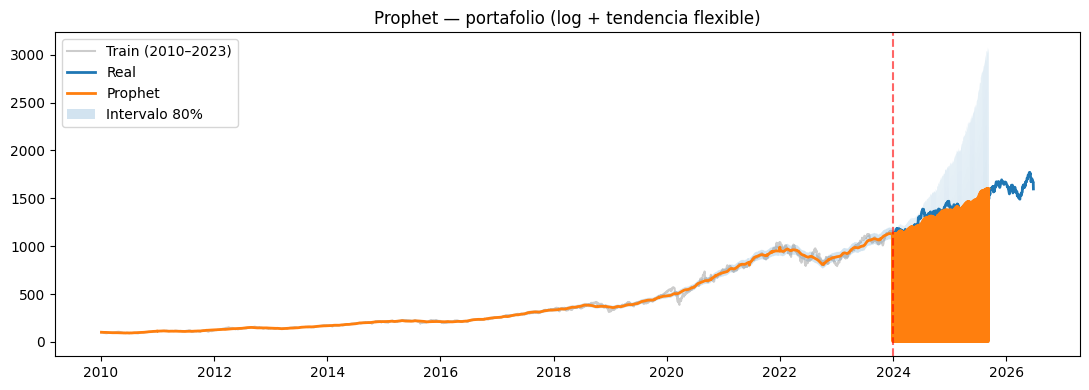

In [6]:
_, pred_full, _ = entrenar_prophet(train["PORTAFOLIO"], test["PORTAFOLIO"])

plt.figure(figsize=(11, 4))
plt.plot(train["PORTAFOLIO"]["ds"], train["PORTAFOLIO"]["y"], color="gray", alpha=0.4, label="Train (2010–2023)")
plt.plot(test["PORTAFOLIO"]["ds"], test["PORTAFOLIO"]["y"], label="Real", linewidth=2)
plt.plot(pred_full["ds"], pred_full["yhat"], label="Prophet", linewidth=2)
plt.fill_between(pred_full["ds"], pred_full["yhat_lower"], pred_full["yhat_upper"], alpha=0.2, label="Intervalo 80%")
plt.axvline(pd.to_datetime(FECHA_CORTE), color="red", linestyle="--", alpha=0.6)
plt.title("Prophet — portafolio (log + tendencia flexible)")
plt.legend()
plt.tight_layout()
plt.show()

## 3 — Backtesting (2024 → hoy)

Comparamos **real (`y`)** vs **predicho (`yhat`)** en el periodo que el modelo no vio al entrenar. Métrica: **MAPE** (error % medio) — más bajo = mejor.


In [7]:
def mape(real, predicho):
    return (abs((real - predicho) / real)).mean() * 100


tabla = []
for nombre, ev in predicciones.items():
    tabla.append({"activo": nombre, "MAPE %": round(mape(ev["y"], ev["yhat"]), 2)})

pd.DataFrame(tabla).sort_values("MAPE %")

,activo,MAPE %
5,PORTAFOLIO,4.69
0,AAPL,7.20
4,JNJ,9.12
3,XOM,11.73
2,JPM,18.83
1,MSFT,25.08


### ¿Qué significa la tabla?

**MAPE** = error porcentual medio absoluto en el backtest (2024 → hoy). **Más bajo = mejor.**

| MAPE | Interpretación |
|------|----------------|
| **< 10%** | Prophet siguió bien la serie en ese periodo |
| **10–20%** | Error moderado |
| **> 20%** | Difícil de predecir (sector volátil, shocks, cambio de régimen) |

Los valores **cambian mucho** según hiperparámetros — por eso ajustamos `log(y)`, `changepoint_prior_scale` y festivos antes de evaluar.

**Lectura típica:**
- **Portafolio / JNJ / AAPL** suelen quedar con MAPE bajo si la tendencia reciente es continua.
- **JPM / XOM / MSFT** a veces empeoran: banca, energía y tech tuvieron movimientos fuertes en 2024–2025 que ningún Prophet “genérico” captura del todo.

> MAPE bajo en backtest **no** garantiza ganancias futuras. Solo mide qué tan bien reprodujo el **pasado reciente** que ya conoces.

### Real vs Prophet — portafolio


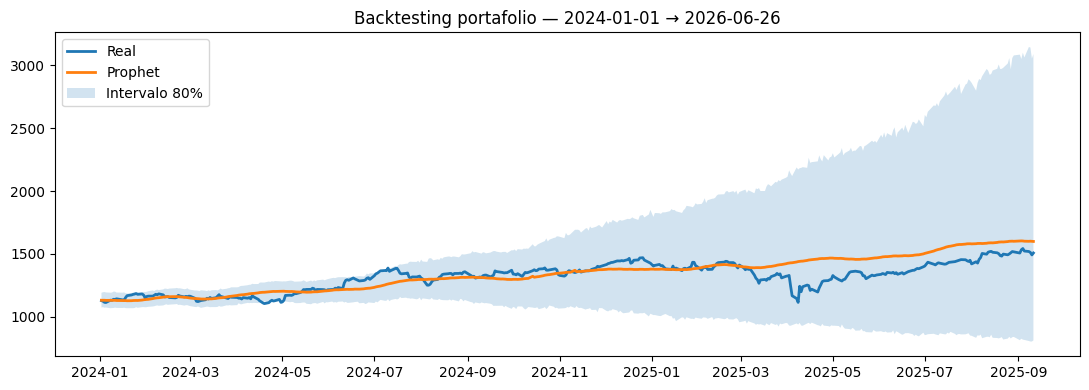

In [8]:
ev = predicciones["PORTAFOLIO"]

plt.figure(figsize=(11, 4))
plt.plot(ev["ds"], ev["y"], label="Real", linewidth=2)
plt.plot(ev["ds"], ev["yhat"], label="Prophet", linewidth=2)
plt.fill_between(ev["ds"], ev["yhat_lower"], ev["yhat_upper"], alpha=0.2, label="Intervalo 80%")
plt.title(f"Backtesting portafolio — {FECHA_CORTE} → {FIN}")
plt.legend()
plt.tight_layout()
plt.show()

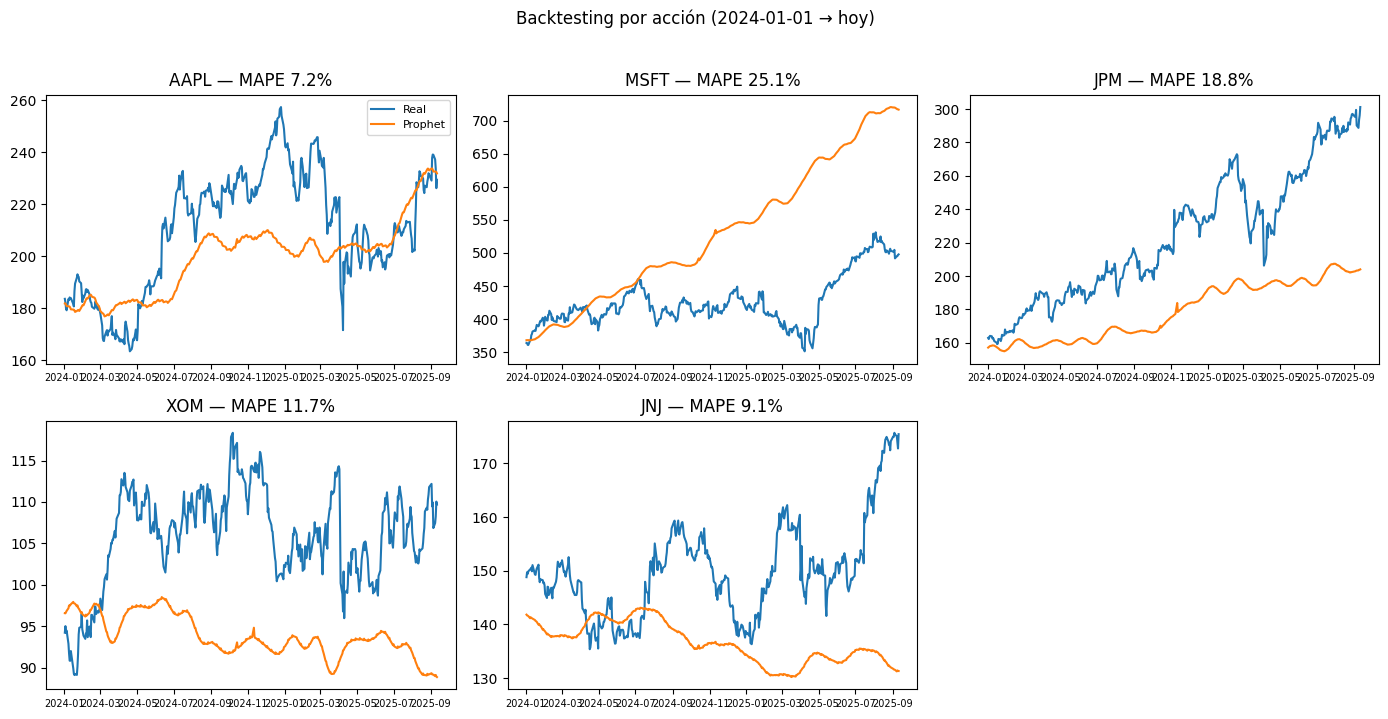

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, nombre in enumerate(TICKERS):
    ev = predicciones[nombre]
    ax = axes[i]
    ax.plot(ev["ds"], ev["y"], label="Real", linewidth=1.5)
    ax.plot(ev["ds"], ev["yhat"], label="Prophet", linewidth=1.5)
    ax.set_title(f"{nombre} — MAPE {mape(ev['y'], ev['yhat']):.1f}%")
    ax.tick_params(axis="x", labelsize=7)
    if i == 0:
        ax.legend(fontsize=8)

axes[-1].axis("off")
fig.suptitle(f"Backtesting por acción ({FECHA_CORTE} → hoy)", y=1.02)
plt.tight_layout()
plt.show()

**Cierre.** Portafolio equiponderado de 5 acciones, entrenamiento 2010–2023, backtesting **2024 a la fecha**. Prophet no “adivina” el mercado — mide qué tan bien extrapola tendencia y estacionalidad al pasado reciente.

Prueba cambiar `TICKERS`, `FECHA_CORTE` o el peso del portafolio.

> Esto **no** es consejo financiero — es práctica de forecasting con Prophet.
